In [2]:
import pymnet
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import openpyxl

# Calculate Material KPIs

# Calculate Energy KPIs

In [ ]:
def TJ_to_MWh(tj):    return tj / 3.6
def MWh_to_TJ(mwh):    return mwh * 3.6
def kWh_to_MWh(kwh):    return kwh / 1000
def MWh_to_kWh(mwh):    return mwh * 1000
def TJ_to_GJ(tj):    return tj * 1000
def GJ_to_TJ(gj):    return gj / 1000

def load_energy_kpi_data():
    # Load "Industrial_Park_Data_2026_KPI.xlsx" sheet "Energy_KPI_export" into a pandas DataFrame
    file_path = "Industrial_Park_Data_2026_KPI.xlsx"
    sheet_name = "Energy_KPI_export"
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    return df

def unpivot_energy_dataframe(df):
    # unpivot the dataframe to wide format
    df_wide = df.pivot(index="Company", columns="Input_Output")
    # flatten the multiindex columns
    df_wide.columns = [f"{col[1]}_{col[0]}" for col in df_wide.columns]
    # reset the index to make "Company" a column again
    df_wide = df_wide.reset_index()
    return df_wide

def transform_energy_dataframe(df):
    # Convert "Input_Electricity - kWh/y" and "Output_Electricity - kWh/y" from kWh to TJ => And rename columns to "Input_Electricity" and "Output_Electricity"
    df["Input_Electricity - kWh/y"] = MWh_to_TJ(kWh_to_MWh(df["Input_Electricity - kWh/y"]))
    df["Output_Electricity - kWh/y"] = MWh_to_TJ(kWh_to_MWh(df["Output_Electricity - kWh/y"]))
    df = df.rename(columns={"Input_Electricity - kWh/y": "Input_Electricity", "Output_Electricity - kWh/y": "Output_Electricity"})

    # Calculate Total Energy Input and Total Energy Output for each company => All columns with "input" and "output" in their names
    df["Total_Energy_Input"] = df.filter(regex="Input").sum(axis=1)
    df["Total_Energy_Output"] = df.filter(regex="Output").sum(axis=1)

    return df

# KPI 1: Energy Intensity per unit of product (TJ/kt)
def calculate_kpi_1(df):
    df["KPI_1_Energy_Intensity_TJ/kt"] = None
    return df

# KPI 2: Process Energy Efficiency (PEE) = Total Energy Consumption / Total Energy Output
def calculate_kpi_2(df):
    df["KPI_2_Process_Energy_Efficiency"] = df["Total_Energy_Input"] / df["Total_Energy_Output"]
    return df

# KPI 3: Total energy consumption (GJ/year)
def calculate_kpi_3(df):
    df["KPI_3_Total_Energy_Consumption_GJ/year"] = TJ_to_GJ(df["Total_Energy_Input"])
    return df

# KPI 4: Cooling water consumption (kt/year)
def calculate_kpi_4(df):
    df["KPI_4_Cooling_Water_Consumption_kt/year"] = None
    return df

# KPI 5: Estimated GHG Emissions
    # Assumption: All plant operations are powered entirely by natural gas with an emission factor of 55.89 tCO2/TJ (VEKA & VMM, 2026).
def calculate_kpi_5(df):
    emission_factor = 55.89  # tCO2/TJ
    df["KPI_5_Estimated_GHG_Emissions_tCO2/year"] = df["Total_Energy_Input"] * emission_factor
    return df

def calculate_all_kpis(df):
    df = calculate_kpi_1(df)
    df = calculate_kpi_2(df)
    df = calculate_kpi_3(df)
    df = calculate_kpi_4(df)
    df = calculate_kpi_5(df)
    return df

df = load_energy_kpi_data()
df = unpivot_energy_dataframe(df)
df = transform_energy_dataframe(df)
df = calculate_all_kpis(df)

display(df)

/home/rud/Documents/01_IE/08_INTR/.venv_INTR/lib64/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Company,Input_Very low pressure steam,Output_Very low pressure steam,Input_Low pressure steam,Output_Low pressure steam,Input_Mid pressure steam,Output_Mid pressure steam,Input_High pressure steam,Output_High pressure steam,Input_Very High pressure steam,...,Output_Fired Heat,Input_Electricity,Output_Electricity,Total_Energy_Input,Total_Energy_Output,KPI_1_Energy_Intensity_TJ/kt,KPI_2_Process_Energy_Efficiency,KPI_3_Total_Energy_Consumption_GJ/year,KPI_4_Cooling_Water_Consumption_kt/year,KPI_5_Estimated_GHG_Emissions_tCO2/year
0,Aromatics plant,1982.317447,1923.468303,1462.269308,428.768891,3899.123973,0.000000,1489.084722,0.000000,NaN,...,NaN,1.535953e+05,0.000000e+00,1.694331e+05,2.352237e+03,None,72.030623,1.694331e+08,None,9.469617e+06
1,Biogas plant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.491798e+01,NaN,1.499665e+04,0.000000e+00,None,inf,1.499665e+07,None,8.381628e+05
2,CHP plant,NaN,NaN,0.000000,696.860513,0.000000,583.547351,0.000000,506.358548,NaN,...,0.0,1.487621e+06,3.020513e+06,1.489377e+06,3.022300e+06,None,0.492796,1.489377e+09,None,8.324128e+07
3,DME plant,0.000000,52.063630,0.000000,63.969345,445.082362,0.000000,0.000000,0.000000,NaN,...,NaN,6.993659e+04,0.000000e+00,7.104102e+04,1.160330e+02,None,612.248512,7.104102e+07,None,3.970482e+06
4,Methanol plant,NaN,NaN,377.105488,183.953288,211.183072,670.839293,0.000000,708.810748,NaN,...,NaN,6.911654e+05,0.000000e+00,6.958880e+05,1.563603e+03,None,445.054083,6.958880e+08,None,3.889318e+07
5,Olefins plant,NaN,NaN,8961.989991,3063.072659,7509.859698,11548.908880,0.000000,6879.155104,0.0,...,NaN,7.205463e+05,1.549558e+05,7.524189e+05,1.787069e+05,None,4.210352,7.524189e+08,None,4.205269e+07


# Merge KPIs and plot

In [4]:
# Import the excel
energy_kpis_df = pd.read_excel("energy KPI Calculations.xlsx", sheet_name="KPI_Summary_Ch5")
energy_kpis_units_df = pd.read_excel("energy KPI Calculations.xlsx", sheet_name="KPI_Units")

display(energy_kpis_df)
display(energy_kpis_units_df)

print(energy_kpis_df["Company"].tolist())


,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions
0,CHP plant,1072.46,-1.4594,3113.28,0,0.000,0,174.00
1,Olefins plant,245515.38,-0.7345,32530.33,0,43.374,0,1818.12
2,Aromatics plant,119745.82,-0.1472,15977.94,0,32.399,0,893.01
3,Biogas plant,0.00,0.0000,19125.62,0,318.760,0,1068.93
4,Methanol plant,65891.82,-0.2921,5353.00,0,17.843,0,299.18
5,DME plant,10508.28,-0.0993,1168.25,0,8.345,0,65.29
6,Total,442733.76,-2.7325,58142.80,0,101.961,0,4253.24


,KPI,Unit
0,Cooling water consumption,kt/y
1,Process Energy Efficiency,%
2,Total Energy consumption,GJ/y
3,Renewable energy share,%
4,Energy Intensity per unit,TJ/kt
5,By-product Energy Recovery,%
6,Estimated GHG Emissions,tCO2/year


['CHP plant', 'Olefins plant', 'Aromatics plant', 'Biogas plant', 'Methanol plant', 'DME plant', 'Total']


In [5]:

material_df_kpi = pd.DataFrame({
    "Company"           : ["Methanol plant", "DME plant", "Aromatics plant", "Olefins plant", "CHP plant", "Biogas plant"],
    "material_intensity"  : [5.46,1.39,2.52,9.74,None,3.94],
    "GHG_Scope_1"       : [1.2223, 0, 0, 0.6673, 0.2481, 0.3735],
    "Recycled Input Materials" : [0.0, 0.0, 0.0, 0.0, 0.0, 1],
    "E-factor" : [5.17978982, 1.97E-03, 1.592456081, 9.3354736, 0, 0],
    "WW Generation Rate" : [46.93, 1220.9, 100.07, 99.66, 0, 0]
})

display(material_df_kpi)

,Company,material_intensity,GHG_Scope_1,Recycled Input Materials,E-factor,WW Generation Rate
0,Methanol plant,5.46,1.2223,0.0,5.179790,46.93
1,DME plant,1.39,0.0000,0.0,0.001970,1220.90
2,Aromatics plant,2.52,0.0000,0.0,1.592456,100.07
3,Olefins plant,9.74,0.6673,0.0,9.335474,99.66
4,CHP plant,NaN,0.2481,0.0,0.000000,0.00
5,Biogas plant,3.94,0.3735,1.0,0.000000,0.00


In [6]:
# Merge the two dataframes on the company name
merged_df = pd.merge(energy_kpis_df, material_df_kpi, left_on='Company', right_on='Company')

# Make something to determine which columns are from either material or energy KPIs
energy_kpi_columns = energy_kpis_df.columns.tolist()
material_kpi_columns = material_df_kpi.columns.tolist()

display(merged_df)

,Company,Cooling water consumption,Process Energy Efficiency,Total Energy consumption,Renewable energy share,Energy Intensity per unit,By-product Energy Recovery,Estimated GHG Emissions,material_intensity,GHG_Scope_1,Recycled Input Materials,E-factor,WW Generation Rate
0,CHP plant,1072.46,-1.4594,3113.28,0,0.000,0,174.00,NaN,0.2481,0.0,0.000000,0.00
1,Olefins plant,245515.38,-0.7345,32530.33,0,43.374,0,1818.12,9.74,0.6673,0.0,9.335474,99.66
2,Aromatics plant,119745.82,-0.1472,15977.94,0,32.399,0,893.01,2.52,0.0000,0.0,1.592456,100.07
3,Biogas plant,0.00,0.0000,19125.62,0,318.760,0,1068.93,3.94,0.3735,1.0,0.000000,0.00
4,Methanol plant,65891.82,-0.2921,5353.00,0,17.843,0,299.18,5.46,1.2223,0.0,5.179790,46.93
5,DME plant,10508.28,-0.0993,1168.25,0,8.345,0,65.29,1.39,0.0000,0.0,0.001970,1220.90


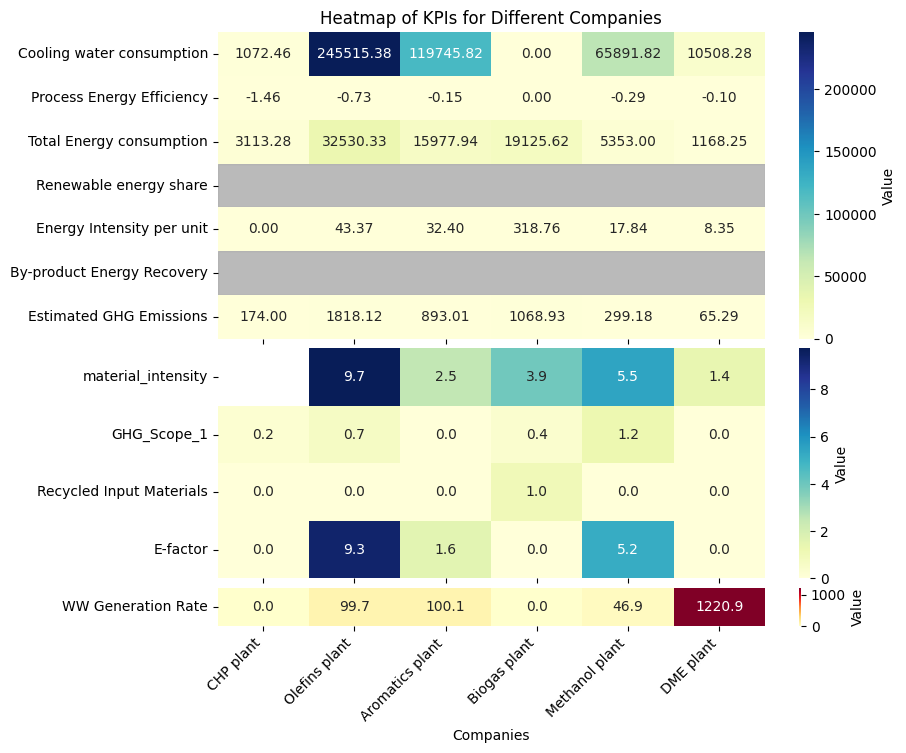

In [7]:
# Make a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

def plot_kpi_heatmap(merged_df, energy_kpi_columns, material_kpi_columns, normalized=False):

    # If normalized is True, plot all on the same scale, otherwise plot on their own scales
        # The values are already normalized in the merged_df if normalized is True, so we can just plot them as is
    if normalized:
        # Create figure
        fig, ax = plt.subplots(figsize=(9, 9))
        # Create heatmap for all KPIs
        mark_row_index = energy_kpi_columns[1:].index("Renewable energy share")
        mark_row_index = [mark_row_index, energy_kpi_columns[1:].index("By-product Energy Recovery")]
        for idx in mark_row_index:
            ax.add_patch(plt.Rectangle((0, idx), len(merged_df.columns), 1, fill=True, color='darkgrey', alpha=0.8))
        
        sns.heatmap(merged_df.set_index("Company")[energy_kpi_columns[1:] + material_kpi_columns[1:]].T, annot=True, cmap="YlGnBu", ax=ax, 
                    cbar_kws={'label': 'Normalized Value'}, fmt='.2f')
        ax.set_title("Heatmap of Normalized KPIs for Different Companies")
        ax.set_xlabel("KPIs")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        plt.tight_layout()
        plt.show()
        return

    # Separate the outlier KPI from the rest
    material_outlier_kpi = "WW Generation Rate"
    material_kpi_columns_no_outlier = [col for col in material_kpi_columns if col != material_outlier_kpi]

    # Prepare data for both heatmaps
    energy_data = merged_df.set_index("Company")[energy_kpi_columns[1:]].T
    material_data = merged_df.set_index("Company")[material_kpi_columns_no_outlier[1:]].T
    material_outlier_data = merged_df.set_index("Company")[[material_outlier_kpi]].T

    # Create figure with three subplots (different heights for main vs single row)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), 
                                        gridspec_kw={'height_ratios': [len(energy_kpi_columns), len(material_kpi_columns), 1], 'hspace': 0.05})

    # Main heatmap for energy KPIs
    # Mark the rows for "Renewable energy share" and "By-product Energy Recovery" in a dark grey color and hide its values
    mark_row_index = energy_kpi_columns[1:].index("Renewable energy share")
    mark_row_index = [mark_row_index, energy_kpi_columns[1:].index("By-product Energy Recovery")]
    for idx in mark_row_index:
        energy_data.iloc[idx, :] = None  # Hide values by setting to None
        ax1.add_patch(plt.Rectangle((0, idx), len(energy_data.columns), 1, fill=True, color='darkgrey', alpha=0.8))
    # Create heatmap
    sns.heatmap(energy_data, annot=True, cmap="YlGnBu", ax=ax1, 
                cbar_kws={'label': 'Value'}, fmt='.2f')
    ax1.set_title("Heatmap of KPIs for Different Companies")
    ax1.set_xlabel("")
    ax1.set_xticklabels([])  # Hide x labels on plot


    # Secondary heatmap for material KPIs (excluding outlier)
    hm2 = sns.heatmap(material_data, annot=True, cmap="YlGnBu", ax=ax2,
                cbar_kws={'label': 'Value'}, fmt='.1f')
    ax2.set_xlabel("")
    ax2.set_xticklabels([])  # Hide x labels on plot

    # Third heatmap for the material outlier KPI
    hm3 = sns.heatmap(material_outlier_data, annot=True, cmap="YlOrRd", ax=ax3,
                cbar_kws={'label': 'Value'}, fmt='.1f')
    ax3.set_xlabel("Companies")
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
    ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0)

    # Save and show the plot
    # plt.tight_layout()
    plt.subplots_adjust(left=0.22, right=0.98, bottom=0.22)
    plt.show()
    # plt.savefig("data_exploration/export/kpi_heatmap.png", dpi=150)
    # print("Saved to data_exploration/export/kpi_heatmap.png")

plot_kpi_heatmap(merged_df, energy_kpi_columns, material_kpi_columns)


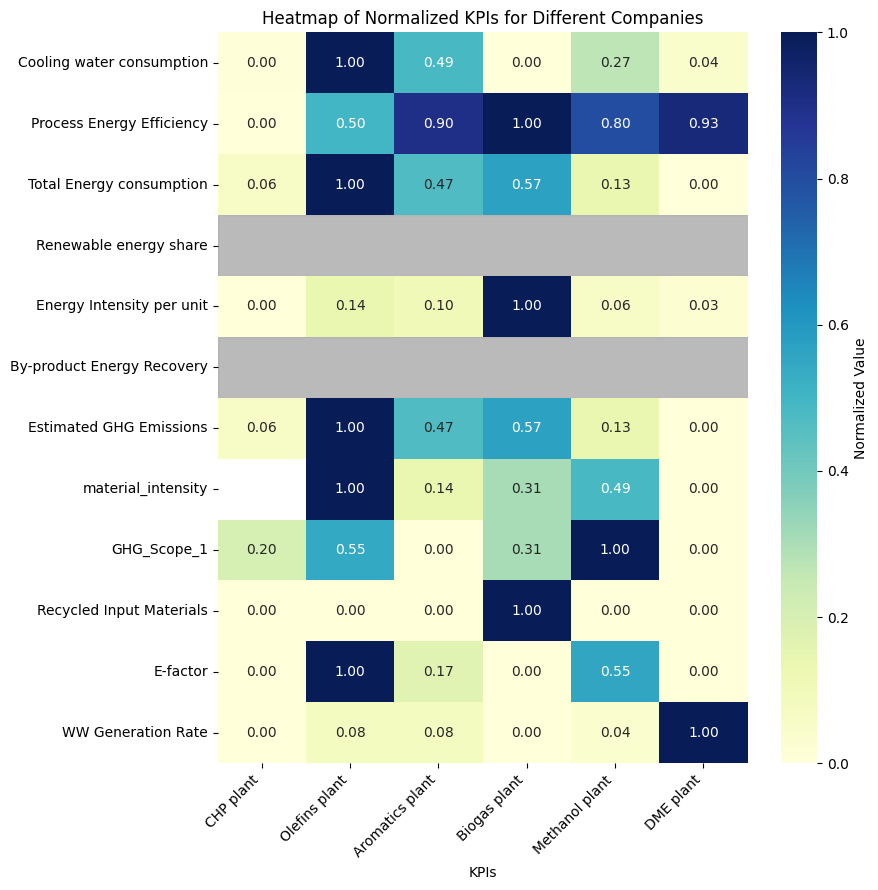

In [8]:
# Create a df of the kpis that are all normalized to be between 0 and 1 (the highest being 1)
normalized_kpis = merged_df.copy()
for col in energy_kpi_columns[1:] + material_kpi_columns[1:]:
    normalized_kpis[col] = (merged_df[col] - merged_df[col].min()) / (merged_df[col].max() - merged_df[col].min())

# Create a heatmap of the normalized KPIs
plot_kpi_heatmap(normalized_kpis, energy_kpi_columns, material_kpi_columns, normalized=True)

['CHP plant', 'DME plant', 'Olefins plant', 'Aromatics plant', 'Methanol plant', 'Biogas plant']
['Materials', 'Energy']


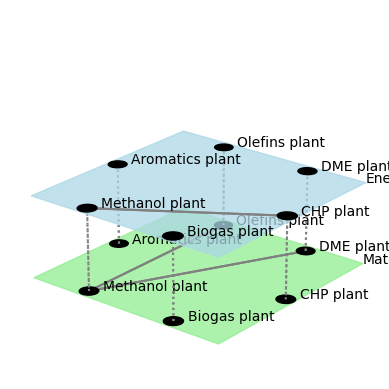

In [9]:
# 2. Create multilayer network
net = pymnet.MultiplexNetwork(couplings='categorical', fullyInterconnected=False)

# Add layers
layers = ['Materials', 'Energy']
for layer in layers:
    net.add_layer(layer)

# Add the nodes: ['CHP plant', 'Olefins plant', 'Aromatics plant', 'Biogas plant', 'Methanol plant', 'DME plant']
companies = ['CHP plant', 'Olefins plant', 'Aromatics plant', 'Biogas plant', 'Methanol plant', 'DME plant']
for company in companies:
    for layer in layers:
        net.add_node(company, layer=layer)


# Add connections
    # Methanol -> DME (Material)
    # Olifins -> Methanol (Material)
    # CHP -> Methanol (Energy)
net['Methanol plant','DME plant','Materials'] = 1
net['Olefins plant','Methanol plant','Materials'] = 1
net['CHP plant','Methanol plant','Energy'] = 1

print(list(net.iter_nodes()))
print(list(net.iter_layers()))

# 3. Visualize
    # Also show nodes without connections
pymnet.draw(net, layout='circular', 
            layerColorDict={'Materials':'lightgreen','Energy':'lightblue'})
plt.show()